<a href="https://colab.research.google.com/github/akashvgeorge/ICT_DSA_26/blob/main/Deep_learning_Casestudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

## Load dataset

In [19]:
# Load & Normalize
(x_train, y_train), (x_test, y_test) = cifar100.load_data()
print("Train:", x_train.shape, "| Test:", x_test.shape)

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

y_train = to_categorical(y_train, 100)
y_test  = to_categorical(y_test,  100)


Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)


# Data Augmentation

In [20]:
# to avoid overfitting

In [21]:
datagen = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rotation_range=15,
    zoom_range=0.1,
)
datagen.fit(x_train)

In [22]:
def conv_bn_relu(model, filters, kernel_size=(3, 3)):
    model.add(layers.Conv2D(
        filters, kernel_size,
        padding='same',
        use_bias=False,               # BN handles bias — no need for Conv bias
        kernel_initializer='he_normal'
    ))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))

## Custom CNN

In [23]:
model_cnn = models.Sequential()

conv_bn_relu(model_cnn, 32)
model_cnn.add(layers.InputLayer(input_shape=(32, 32, 3)))
model_cnn = models.Sequential()

model_cnn.add(layers.Input(shape=(32, 32, 3)))

# Block 1
conv_bn_relu(model_cnn, 32)
conv_bn_relu(model_cnn, 32)
model_cnn.add(layers.MaxPooling2D((2, 2)))
model_cnn.add(layers.Dropout(0.2))

# Block 2
conv_bn_relu(model_cnn, 64)
conv_bn_relu(model_cnn, 64)
model_cnn.add(layers.MaxPooling2D((2, 2)))
model_cnn.add(layers.Dropout(0.3))

# Block 3
conv_bn_relu(model_cnn, 128)
conv_bn_relu(model_cnn, 128)
model_cnn.add(layers.MaxPooling2D((2, 2)))
model_cnn.add(layers.Dropout(0.3))

# Block 4 — deeper features, NO pooling (already at 4×4)
conv_bn_relu(model_cnn, 256)
conv_bn_relu(model_cnn, 256)
model_cnn.add(layers.Dropout(0.4))

model_cnn.add(layers.GlobalAveragePooling2D())
model_cnn.add(layers.Dense(
    512,
    kernel_initializer='he_normal',
    kernel_regularizer=tf.keras.regularizers.l2(0.0005)
))
model_cnn.add(layers.BatchNormalization())
model_cnn.add(layers.Activation('relu'))
model_cnn.add(layers.Dropout(0.5))
model_cnn.add(layers.Dense(100, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


## Compile the model

In [24]:
model_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


## Model summary

In [11]:
model_cnn.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 8, 8, 128)      │             

 Total params: 1,360,068 (5.19 MB)

 Trainable params: 1,357,124 (5.18 MB)

 Non-trainable params: 2,944 (11.50 KB)

## Callbacks

In [25]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    ),
]

## Train the model

In [13]:
history = model_cnn.fit(
    datagen.flow(x_train, y_train, batch_size=64),
    steps_per_epoch=len(x_train) // 64,
    epochs=100,
    validation_data=(x_test, y_test),
    callbacks=callbacks
)

Epoch 1/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 60s 56ms/step - accuracy: 0.0776 - loss: 4.5012 - val_accuracy: 0.1223 - val_loss: 3.9889 - learning_rate: 0.0010
Epoch 2/100
  1/781 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.1250 - loss: 4.2303

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.1250 - loss: 4.2303 - val_accuracy: 0.1240 - val_loss: 3.9666 - learning_rate: 0.0010
Epoch 3/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 43ms/step - accuracy: 0.1608 - loss: 3.6984 - val_accuracy: 0.2112 - val_loss: 3.4601 - learning_rate: 0.0010
Epoch 4/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1875 - loss: 3.4203 - val_accuracy: 0.2129 - val_loss: 3.4785 - learning_rate: 0.0010
Epoch 5/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.2222 - loss: 3.2742 - val_accuracy: 0.2474 - val_loss: 3.1646 - learning_rate: 0.0010
Epoch 6/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.1406 - loss: 3.0421 - val_accuracy: 0.2457 - val_loss: 3.1716 - learning_rate: 0.0010
Epoch 7/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 44ms/step - accuracy: 0.2640 - loss: 2.9960 - val_accuracy: 0.2936 - val_loss: 2.8182 - learning_rate: 0.0010
Epoch 8/100
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3125 - loss: 2.7994 -

## Model evaluation

In [14]:
cnn_loss, cnn_acc = model_cnn.evaluate(x_test, y_test)

print("Test Accuracy:", cnn_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5478 - loss: 1.6996
Test Accuracy: 0.5478000044822693


## plotting

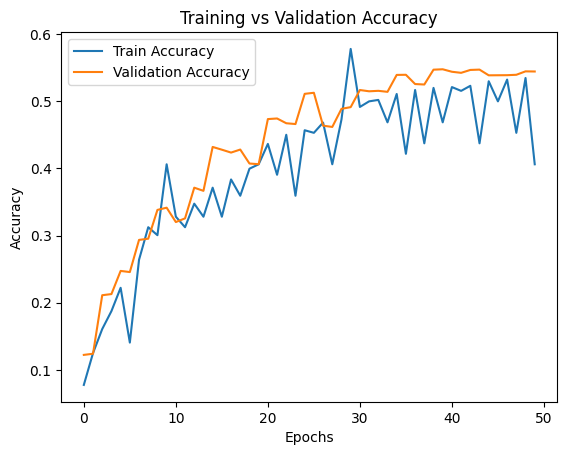

In [15]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()

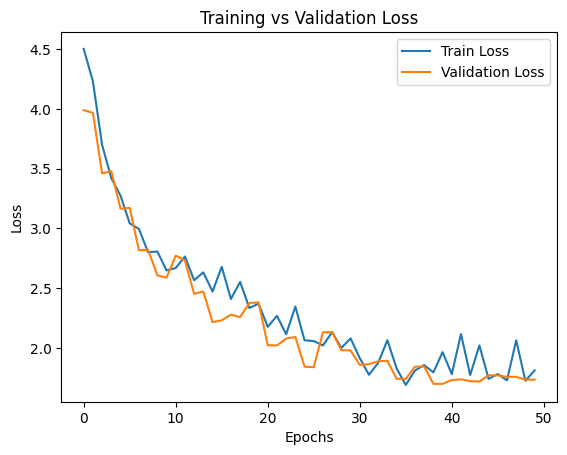

In [16]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()

# VGG16

## Load dataset

In [3]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()
print(f"Train: {x_train.shape} | Test: {x_test.shape}")

x_train = x_train.astype('float32')
x_test  = x_test.astype('float32')

y_train = to_categorical(y_train, 100)
y_test  = to_categorical(y_test,  100)

Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)


In [4]:
# ── 3. Data Augmentation (on original 32×32 — model will resize internally) ──
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    fill_mode='nearest'
)
datagen.fit(x_train)

In [5]:
IMG_SIZE = 96

inputs = tf.keras.Input(shape=(32, 32, 3))

# Resize per batch — only one batch in memory at a time (no RAM crash)
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)

# VGG16 preprocessing inside model
x = layers.Lambda(
    lambda img: preprocess_input(img),
    name='vgg16_preprocessing'
)(x)

In [6]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model(x, training=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## One-hot enoding

In [7]:
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, kernel_regularizer=l2(0.0005))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.5)(x)

x = layers.Dense(256, kernel_regularizer=l2(0.0005))(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(100, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16_preprocessing (Lambda)    │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,137,444 (57.74 MB)

 Trainable params: 421,220 (1.61 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [8]:
BATCH_SIZE      = 32
STEPS_PER_EPOCH = len(x_train) // BATCH_SIZE

def get_callbacks(checkpoint_name, patience_es=6, patience_lr=3):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience_es,
            restore_best_weights=True,
            verbose=1
        ),
        ModelCheckpoint(
            checkpoint_name,
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=patience_lr,
            min_lr=1e-7,
            verbose=1
        ),
    ]

In [9]:
print("\n" + "="*60)
print("PHASE 1: Training head only (VGG16 base fully frozen)")
print("="*60)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase1 = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=20,
    validation_data=(x_test, y_test),
    callbacks=get_callbacks('best_vgg16_phase1.keras', patience_es=6, patience_lr=3)
)


PHASE 1: Training head only (VGG16 base fully frozen)
Epoch 1/20
1561/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.2160 - loss: 3.7806
Epoch 1: val_accuracy improved from None to 0.51040, saving model to best_vgg16_phase1.keras

Epoch 1: finished saving model to best_vgg16_phase1.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 92s 53ms/step - accuracy: 0.2970 - loss: 3.2245 - val_accuracy: 0.5104 - val_loss: 2.1926 - learning_rate: 0.0010
Epoch 2/20
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 1:49 70ms/step - accuracy: 0.2500 - loss: 3.1135

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.51040 to 0.51120, saving model to best_vgg16_phase1.keras

Epoch 2: finished saving model to best_vgg16_phase1.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.2500 - loss: 3.1135 - val_accuracy: 0.5112 - val_loss: 2.1929 - learning_rate: 0.0010
Epoch 3/20
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.3985 - loss: 2.6967
Epoch 3: val_accuracy improved from 0.51120 to 0.52910, saving model to best_vgg16_phase1.keras

Epoch 3: finished saving model to best_vgg16_phase1.keras
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.4015 - loss: 2.6795 - val_accuracy: 0.5291 - val_loss: 2.1009 - learning_rate: 0.0010
Epoch 4/20
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.2812 - loss: 2.7642
Epoch 4: val_accuracy did not improve from 0.52910
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.2812 - loss: 2.7642 - val_accuracy: 0.5277 - val_loss: 2.1008 - learning_rate: 0.0010
Epoch 5/20
1562/1562 ━━━━━

In [11]:
print("\n" + "="*60)
print("PHASE 2: Fine-tuning last 2 blocks of VGG16 (block4 + block5)")
print("="*60)

base_model.trainable = True
for layer in base_model.layers[:-8]:
    layer.trainable = False

print("\nTrainable layers in base model:")
for layer in base_model.layers:
    print(f"  {layer.name:25s} trainable={layer.trainable}")

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=30,
    validation_data=(x_test, y_test),
    callbacks=get_callbacks('best_vgg16_phase2.keras', patience_es=8, patience_lr=3)
)


PHASE 2: Fine-tuning last 2 blocks of VGG16 (block4 + block5)

Trainable layers in base model:
  input_layer_1             trainable=False
  block1_conv1              trainable=False
  block1_conv2              trainable=False
  block1_pool               trainable=False
  block2_conv1              trainable=False
  block2_conv2              trainable=False
  block2_pool               trainable=False
  block3_conv1              trainable=False
  block3_conv2              trainable=False
  block3_conv3              trainable=False
  block3_pool               trainable=False
  block4_conv1              trainable=True
  block4_conv2              trainable=True
  block4_conv3              trainable=True
  block4_pool               trainable=True
  block5_conv1              trainable=True
  block5_conv2              trainable=True
  block5_conv3              trainable=True
  block5_pool               trainable=True
Epoch 1/30
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.5338 - 

#Graphs


✅ Final Test Accuracy: 75.78%


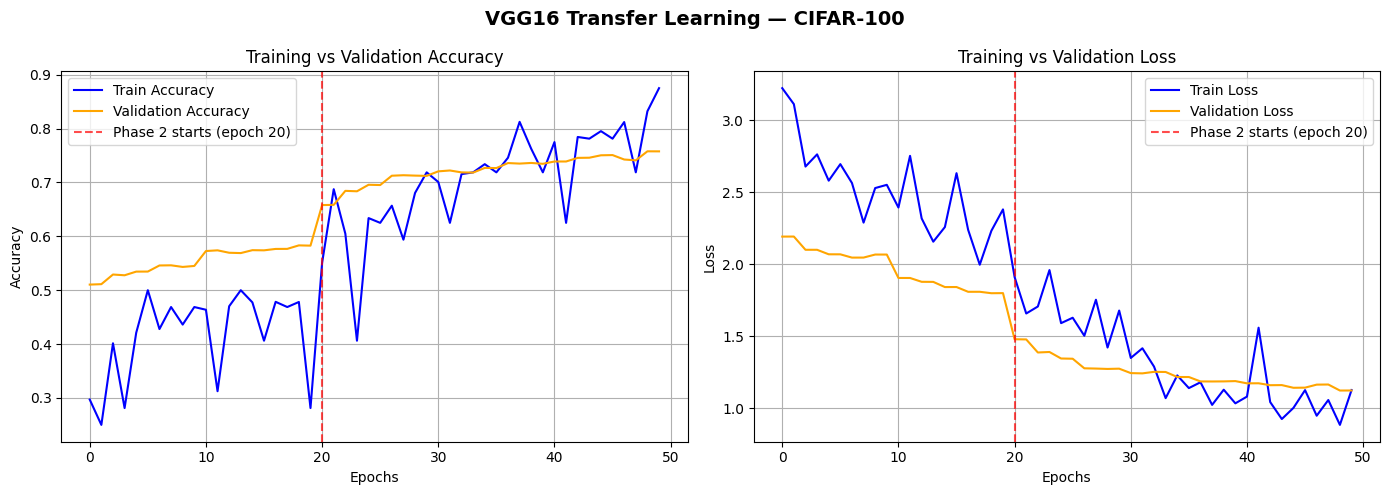

In [14]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\n✅ Final Test Accuracy: {acc * 100:.2f}%")

def plot_history(h1, h2):
    acc      = h1.history['accuracy']      + h2.history['accuracy']
    val_acc  = h1.history['val_accuracy']  + h2.history['val_accuracy']
    loss     = h1.history['loss']          + h2.history['loss']
    val_loss = h1.history['val_loss']      + h2.history['val_loss']
    phase2_start = len(h1.history['accuracy'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(acc,     label='Train Accuracy',      color='blue')
    ax1.plot(val_acc, label='Validation Accuracy', color='orange')
    ax1.axvline(x=phase2_start, color='red', linestyle='--',
                alpha=0.7, label=f'Phase 2 starts (epoch {phase2_start})')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Training vs Validation Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(loss,     label='Train Loss',      color='blue')
    ax2.plot(val_loss, label='Validation Loss', color='orange')
    ax2.axvline(x=phase2_start, color='red', linestyle='--',
                alpha=0.7, label=f'Phase 2 starts (epoch {phase2_start})')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.set_title('Training vs Validation Loss')
    ax2.legend()
    ax2.grid(True)

    plt.suptitle('VGG16 Transfer Learning — CIFAR-100', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('vgg16_training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_phase1, history_phase2)

In [29]:
# VGG accuracy is 75.78% compared to 54.78% in the custom model